# Fase 0: fundamentos de redes neurais com NumPy
**Objetivo:** Compreender o funcionamento dos algoritmos fundamentais de redes neurais.

**Conceitos-chave:** regressão, gradiente descendente, neurônio, função de ativação, *backpropagation*.

### Sumário
**Etapa 0.1: Gradiente Descendente**

*Etapa 0.2: MLP do zero*

*Etapa 0.3: *Backpropagation**

*Etapa 0.4: Autograd simples*

*Mini-projeto 0: A curva de luz de uma supernova Ia*

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Etapa 0.1 — O Algoritmo do Gradiente Descendente

O algoritmo do gradiente descendente tem o objetivo buscar os valores dos parâmetros que minimizam determinada função. Em outras palavras, é um algoritmo de **otimização**.

## 0.1.1 O problema da regressão

A **regressão** é um problema numérico que envolve determinar a relação matemática entre dois conjuntos de valores, isto é, dado um conjunto de valores $x$ e um conjunto de valores $y$, como chegar em $y$ a partir de $x$? A relação matemática mais simples (e que muitas vezes pode ser aproximada manualmente) é a função de primeiro grau,
$$
y = ax +b.
$$
Em um problema de regressão, nosso objetivo é determinar os valores dos parâmetros $a$ e $b$ a partir dos valores para $x$ e $y$ que temos.  Matematicamente, não é um problema complexo. Se conhecemos dois pontos, $x_{1}$ e $x_{2}$, e seus pares, $y_{1}$ e $y_{2}$, podemos determinar os parâmetros unívocamente:
$$
\begin{align*}
a &= \frac{y_{2}-y_{1}}{x_{2}-x_{1}} \\
b &= \frac{y_{2}x_{1}-y_{1}x_{2}}{x_{1}-x_{2}}.
\end{align*}
$$
No entanto, em cenários reais, $x$ e $y$ são **dados**, medidas experimentais ou observacionais. Como todo conjunto de dados, essas medidas estão sujeitas a ruídos e incertezas e, consequentemente, a relação entre dois pontos de dados pode não ser constante tal qual a relação acima nos diz. Assim, o problema da regressão requer que nós encontremos os *melhores* valores de $a$ e $b$ de modo que todos os pontos de dados desviem o mínimo possível da relação matemática acima.

Vamos ver essa diferença na prática. Primeiro, definimos nossa função da forma $y = ax + b$ e inicializamos o vetor $x$. Usamos a função para calcular $y$. Esse cenário, com $x$ e $y$, é o ideal matematicamente: é aquele que nos permite pegar quaisquer dois pares de dados e, deles, calcular o valor *exato* dos parâmetros.

In [2]:
def func(x):
    a = 5
    b = -1
    return a * x + b

x = np.array([1, 2, 3, 4, 5])
y = func(x)
a = []
b = []

for i in range(1, len(x)):
    a.append(float((y[i] - y[i-1])/(x[i] - x[i-1])))
    b.append(float((y[i] * x[i-1] - y[i-1] * x[i]) / (x[i-1] - x[i])))

print(f'a = {a}')
print(f'b = {b}')

a = [5.0, 5.0, 5.0, 5.0]
b = [-1.0, -1.0, -1.0, -1.0]


Perceba que calculamos $a$ e $b$ usando quatro combinações diferentes de pares de dados e todos eles resultaram no exato mesmo valor.

Agora, vamos adicionar "realidade" a esses dados. Adicionaremos ruído gaussiano aleatório a cada um dos pontos de dados. Em um experimento, medidos tanto $x$ quanto $y$ e, consequentemente, ele estão sujeitos a tais ruídos. Se tentarmos repetir o mesmo algoritmo acima para esses novos dados, veremos que os valores encontrados serão diferentes.

In [3]:
np.random.seed(42)
y_gaussian = np.squeeze(y + 0.25 * np.random.randn(1, 5))
x_gaussian = np.squeeze(x + 0.25 * np.random.randn(1, 5))

a_gaussian = []
b_gaussian = []

for i in range(1, len(x)):
    aux = (y_gaussian[i] - y_gaussian[i-1])/(x_gaussian[i] - x_gaussian[i-1])
    a_gaussian.append(float(np.round(aux, 3)))
    aux = float((y_gaussian[i] * x_gaussian[i-1] - y_gaussian[i-1] * x_gaussian[i]) / (x_gaussian[i-1] - x_gaussian[i]))
    b_gaussian.append(float(np.round(aux, 3)))

print(f'a = {a_gaussian}')
print(f'b = {b_gaussian}')

a = [3.331, 6.52, 7.555, 3.64]
b = [0.988, -6.648, -9.953, 5.249]


Como esperado, cada combinação de pares gerou um valor diferente para os parâmetros.

Então, é nesse contexto que se faz necessário termos um algoritmo capaz de estimar o melhor valor para os parâmetros de modo que todos os dados se adequem igualmente.

## 0.1.2 A função de perda

Para que possamos estimar os valores dos parâmetros, é necessário adotarmos alguma métrica. Tratando-se de um problema de otimização, é evidente que precisamos de *algo* para otimizar, nesse caso, iremos **minimizar**. O alvo da nossa minimização é a chamada **função de perda**, que é alguma função matemática que serve como métrica de comparação entre os dados de saída medidos ($y$) e os dados de saída previstos pelo modelo. Uma função de perda muito comum é o **erro quadrático médio** (MSE), definido como
$$
L(a, b) = \frac{1}{N}\sum_{i=1}^{N}(y_{i} - \hat{y}_{i}(a, b))^{2},
$$
em que $L$ é a função de perda, $N$ é o número de dados, $y_{i}$ é i-ésimo dado de saída medido, e $\hat{y}_{i}$ é o i-ésimo dado de saída previsto pelo modelo. Note que a função de perda é uma função dos *parâmetro* via a função do modelo $\hat{y}$, já que os dados são fixos.

Ao minimizarmos essa função, o que estamos fazendo na prática é diminuir o erro absoluto entre os dados medidos e os dados previstos. Como consequência, sabemos que os valores que o modelo está usando para os parâmetros devem estar próximos de seus valores reais, explicando a geração de previsões próximas dos dados. Para minimizá-la, exploraremos com algum algoritmo o espaço dos parâmetros, isto é, variaremos a pequenos passos os valores dos parâmetros de modo que o próximo passo sempre resulte em um valor menor para a função de perda. É necessário, então, que tenhamos alguma forma de avaliar como devemos variar os valores dos parâmetros a fim de aproximarmos do valor mínimo da função de perda.

In [4]:
def MSE(dados, previsoes):
    erro = dados - previsoes
    return np.mean(erro**2)

def modelo(a, b, x):
    return a * x + b

previsao1 = modelo(7, -3, x)
previsao2 = modelo(6, -2, x)
previsao3 = modelo(5, -1, x)

print(f'Previsão 1: MSE = {MSE(y_gaussian, previsao1)}')
print(f'Previsão 2: MSE = {MSE(y_gaussian, previsao2)}')
print(f'Previsão 3: MSE = {MSE(y_gaussian, previsao3)}')

Previsão 1: MSE = 23.080329607872454
Previsão 2: MSE = 5.55928849240855
Previsão 3: MSE = 0.038247376944645355


Perceba que, conforme os valores dos parâmetros $a$ e $b$ foram aproximando-se dos valores reais, a função de perda foi diminuindo drasticamente, atingindo o menor valor possível para os valores exatos dos parâmetros. Idealmente, se usássemos os dados puros, sem ruídos, a função de perda resultaria em zero, pois o modelo preveria exatamente os mesmo dados medidos. Novamente, no mundo real isso é impossível, tendo em vista a natureza estatística das nossas medições. Sendo assim, buscamos sempre um valor baixo para a função de perda, quanto menor, melhor.

## 0.1.3 O gradiente descendente

Nosso objetivo é encontrar o menor valor possível para a função de perda. Fazemos isso alterando os valores dos parâmetros do nosso modelos esperando que, eventualmente, nosso palpite seja próximo dos valores reais. O problema agora é: como escolher o próximo palpite? Obviamente não podemos ficar alterando aleatoriamente, então precisamos de algum mecanismo que nos auxilie a decidir como alterar o parâmetro.

A informação mais importante é em qual **direção** devemos alterar o valor do parâmetro, isto é, devemos aumentá-lo ou diminui-lo? Para isso, usamos a **derivada** da função de perda em relação aos parâmetros. A derivada de uma função em relação a algum parâmetro nos informa o que acontece com a função ao mudarmos o valor desse parâmetro. Uma derivada positiva implica que aumentar o parâmetro aumentará o valor da função, enquanto a derivada negativa implica que aumentar o parâmetro diminuirá a função. Ao escolhermos um valor para o parâmetro, podemos então avaliar a derivada da função de perda em relação a esse parâmetro nesse valor específico e, com base no *sinal* da derivada, decidimos se aumentamos ou diminuimos o parâmetro. Vamos ver se isso realmente nos ajuda a encontrar o menor valor da função de perda.

Primeiro, vamos calcular suas derivadas. Como
$$
L(a, b) = \frac{1}{N}\sum_{i=1}^{N}(y_{i} - \hat{y}_{i}(a, b))^{2} \quad \text{e} \quad \hat{y}_{i} = ax_{i}+b
$$
temos que
$$
\frac{dL}{da} = \frac{dL}{d\hat{y}}\frac{d\hat{y}}{da} = -\frac{2}{N}\sum_{i=1}^{N}(y_{i} - \hat{y}_{i})x_{i}
$$
e
$$
\frac{dL}{db} = \frac{dL}{d\hat{y}}\frac{d\hat{y}}{db} = -\frac{2}{N}\sum_{i=1}^{N}(y_{i} - \hat{y}_{i}).
$$
Vamos implementá-las agora.

In [5]:
def dLda(dados, previsao, x):
    '''Calcula a derivada de L em função de a.'''
    err = dados - previsao
    aux = err * x
    return -2 * np.mean(aux)

def dLdb(dados, previsao):
    '''Calcula a derivada de L em função de b.'''
    err = dados - previsao
    return -2 * np.mean(err)

Vamos escolher nossos palpites iniciais: $a = 3$ e $b=2$. Agora, calculamos nossa previsão usando o modelo, calculamos a loss e avaliamos as derivadas.

In [6]:
a = 3
b = 2

previsao = modelo(a, b, x)
perda = MSE(y_gaussian, previsao)
der_a = dLda(y_gaussian, previsao, x)
der_b = dLdb(y_gaussian, previsao)

print(f'Parâmetros:\na = {a}\nb = {b}\n')
print(f'MSE = {perda}')
print(f'dL/da = {der_a}')
print(f'dL/db = {der_b}')

Parâmetros:
a = 3
b = 2

MSE = 17.76666365885429
dL/da = -26.708460371698642
dL/db = -6.229501487162544


A função de perda resultou em um valor consideravelmente grande, indicando que há erro considerável. A derivada em relação ao parâmetro $a$ é **negativa**, indicando que devemos aumentar o valor de $a$ para diminuir a função de perda. Por outro lado, obtemos que a derivada de $b$ *também* é **negativa**, o que parece errado, já que $2$ é maior que $-1$ e, portanto, deveríamos *diminuir* $b$, não aumentá-lo. A resposta está em como as derivadas são calculadas. Por exemplo, a derivada de $L$ em relação a $b$, nesse primeiro caso, é calculada considerando que $a=3$ (já que é uma derivada parcial, no fim das contas). Ou seja, com $a$ fixado em $3$, e $b$ livre para variar, o mínimo da função de perda está em e $b>2$, por isso a derivada negativa. No entanto, os dois parâmetros são atualizados *simultaneamente*. Então, na próxima iteração, iremos mudar tanto $a$ quanto $b$ e, ao calcularmos as derivadas, iremos considerar $a$ e $b$ como tendo esses novos valores, o que impacta diretamente no valor das derivadas.

Vamos atualizar os parâmetros. Aqui surge outra dúvida: em quanto variar os valores? Usaremos a própria derivada para isso por meio da expressão
$$
\theta_{n+1} = \theta_{n} - \eta \cdot \left. \frac{dL}{\theta}\right| _{\theta_{n}}.
$$
Ou seja, se o valor atual for $\theta_{n}$, iremos **subtrair** a derivada da função de perda em relação ao parâmetro $\theta$ avaliada em $\theta_{n}$, já que buscamos o mínimo de $L$. Além disso, iremos multiplicar a derivada por um valor arbitrário $\eta$, que é o que nos permite regular a distância entre um palpite e outro. Por exemplo, a derivada em relação a $a$ é $-26.71$, se simplesmente subtraíssemos esse valor de $a$, iríamos chegar em $a = 29.71$, o que é muito mais distante que o chute original. Parâmetros que são definidos *a priori*, isto é, antes de rodar o modelo, são chamados de **hiperparâmetros**. É comum usarmos $\eta < 0.01$. Vamos atualizar os parâmetros e rodar de novo o ajuste.

In [7]:
eta = 0.001

a -= eta * der_a
b -= eta * der_b

previsao = modelo(a, b, x)
perda = MSE(y_gaussian, previsao)
der_a = dLda(y_gaussian, previsao, x)
der_b = dLdb(y_gaussian, previsao)

print(f'Parâmetros:\na = {a}\nb = {b}\n')
print(f'MSE = {perda}')
print(f'dL/da = {der_a}')
print(f'dL/db = {der_b}')

Parâmetros:
a = 3.0267084603716987
b = 2.0062295014871627

MSE = 17.023398964109237
dL/da = -26.08349723459829
dL/db = -6.056791721958026


Como podemos ver, o padrão se repete: derivadas negativas, e, como esperado, obtemos um MSE menor que o palpite anterior. Vamos rodar algumas iterações usando um *loop* `for`:

In [8]:
n = 25 # Número de iterações
for i in range(n):
    previsao = modelo(a, b, x)
    perda = MSE(y_gaussian, previsao)
    der_a = dLda(y_gaussian, previsao, x)
    der_b = dLdb(y_gaussian, previsao)

    new_a = a - eta * der_a
    new_b = b - eta * der_b

    if (i+1)%5 == 0 or i==0: # Imprime os resultados a cada 5 iterações
        print(30*'-'+f'\nIteração {i+1}\n')
        print(f'Parâmetros:\na = {a}\nb = {b}\n')
        print(f'MSE = {perda}')
        print(f'dL/da = {der_a}')
        print(f'dL/db = {der_b}\n')

    # Atualiza os valores para a próxima iteração
    a = new_a
    b = new_b

------------------------------
Iteração 1

Parâmetros:
a = 3.0267084603716987
b = 2.0062295014871627

MSE = 17.023398964109237
dL/da = -26.08349723459829
dL/db = -6.056791721958026

------------------------------
Iteração 5

Parâmetros:
a = 3.127438783986518
b = 2.029460879544798

MSE = 14.38148512970879
dL/da = -23.728041846726452
dL/db = -5.405947024153839

------------------------------
Iteração 10

Parâmetros:
a = 3.24066409305129
b = 2.054994716165623

MSE = 11.7158538028273
dL/da = -21.083882027576518
dL/db = -4.675527496523557

------------------------------
Iteração 15

Parâmetros:
a = 3.3412795162033535
b = 2.0770456616445716

MSE = 9.616546621618218
dL/da = -18.738037045357437
dL/db = -4.027733066653281

------------------------------
Iteração 20

Parâmetros:
a = 3.4307076914079175
b = 2.096007747254303

MSE = 7.962969355213528
dL/da = -16.65684467719863
dL/db = -3.453239844206432

------------------------------
Iteração 25

Parâmetros:
a = 3.5102107243875564
b = 2.1122305394

Ao fim das iterações, vemos que o MSE diminui bastante. Apesar disso, o valor dos parâmetros continua distante do valor ideal. Vamos rodar mais iterações.

In [9]:
n = 1100 # Número de iterações
for i in range(n):
    previsao = modelo(a, b, x)
    perda = MSE(y_gaussian, previsao)
    der_a = dLda(y_gaussian, previsao, x)
    der_b = dLdb(y_gaussian, previsao)

    new_a = a - eta * der_a
    new_b = b - eta * der_b

    if (i+1)%100 == 0 or i==0: # Imprime os resultados a cada 100 iterações
        print(30*'-'+f'\nIteração {i+1}\n')
        print(f'Parâmetros:\na = {a}\nb = {b}\n')
        print(f'MSE = {perda}')
        print(f'dL/da = {der_a}')
        print(f'dL/db = {der_b}\n')

    # Atualiza os valores para a próxima iteração
    a = new_a
    b = new_b

------------------------------
Iteração 1

Parâmetros:
a = 3.525021165586098
b = 2.1151743155004668

MSE = 6.43487640441793
dL/da = -14.466948835801684
dL/db = -2.8490258626450227

------------------------------
Iteração 100

Parâmetros:
a = 4.0969046482103995
b = 2.160805046024814

MSE = 1.787677014630243
dL/da = -1.6117278349209776
dL/db = 0.6735364941494787

------------------------------
Iteração 200

Parâmetros:
a = 4.176075403253253
b = 2.0725919544011657

MSE = 1.6354868286630455
dL/da = -0.3992497737200814
dL/db = 0.9721348411593048

------------------------------
Iteração 300

Parâmetros:
a = 4.2081037652035
b = 1.9749834002118107

MSE = 1.529864788973336
dL/da = -0.28027713595077086
dL/db = 0.9690879044820783

------------------------------
Iteração 400

Parâmetros:
a = 4.235007607066381
b = 1.8794958915974254

MSE = 1.4314544306909514
dL/da = -0.26131766665371503
dL/db = 0.9395359384305906

------------------------------
Iteração 500

Parâmetros:
a = 4.260646638523828
b = 1.

Conforme nos aproximamos do mínimo, as derivadas ficam menores e, consequentemente, a aproximação dos parâmetros fica mais lenta. Temos que rodar mais iterações. Podemos escolher um critério de parada, por exemplo:
$$
L_{n} - L_{n-p} < 10^{-4}.
$$
Nesse caso, nosso *loop* irá parar quando a quarta casa decimal não mudar após $p$ iterações. Vamos rodar esse algoritmo:

In [10]:
parada = 10e-4
err = 1
p = 100
i = 1
while err > parada:
    previsao = modelo(a, b, x)
    new_perda = MSE(y_gaussian, previsao)
    der_a = dLda(y_gaussian, previsao, x)
    der_b = dLdb(y_gaussian, previsao)

    new_a = a - eta * der_a
    new_b = b - eta * der_b

    if (i+1)%p == 0 or i==0: # Imprime os resultados a cada 100 iterações
        print(30*'-'+f'\nIteração {i+1}\n')
        print(f'Parâmetros:\na = {a}\nb = {b}\n')
        print(f'MSE = {perda}')
        print(f'dL/da = {der_a}')
        print(f'dL/db = {der_b}\n')

    # Atualiza os valores para a próxima iteração
    a = new_a
    b = new_b

    # Calcula a diferença entre os MSE
    if (i)%100 == 0:
        err = perda - new_perda
        perda = new_perda

    i += 1

    if err < parada: # Imprime o último resultado
        print(30*'-'+f'\nIteração {i+2}\n')
        print(f'Parâmetros:\na = {a}\nb = {b}\n')
        print(f'MSE = {perda}')
        print(f'dL/da = {der_a}')
        print(f'dL/db = {der_b}\n')

------------------------------
Iteração 100

Parâmetros:
a = 4.417341846390387
b = 1.221376413843356

MSE = 0.9010519031266224
dL/da = -0.1986812680500023
dL/db = 0.7173024188664868

------------------------------
Iteração 200

Parâmetros:
a = 4.436881107409984
b = 1.1508334817893913

MSE = 0.8437649521985501
dL/da = -0.1920751179426528
dL/db = 0.6934521208761399

------------------------------
Iteração 300

Parâmetros:
a = 4.455770688203066
b = 1.0826361014949044

MSE = 0.7902242480542923
dL/da = -0.1856886222617497
dL/db = 0.6703948450456636

------------------------------
Iteração 400

Parâmetros:
a = 4.4740321906305764
b = 1.0167062833882508

MSE = 0.7401848070677726
dL/da = -0.17951447749645233
dL/db = 0.6481042233974161

------------------------------
Iteração 500

Parâmetros:
a = 4.491686498291679
b = 0.9529686310501934

MSE = 0.6934176661744254
dL/da = -0.17354562298054824
dL/db = 0.6265547646879153

------------------------------
Iteração 600

Parâmetros:
a = 4.508753800406055

No total, foram $7228$ iterações para que a quarta casa decimal estabilizasse entre $100$ iterações. Os resultados obtidos foram $a=4.93$ e $b=-0.62$. O valor de $a$, por multiplicar $x$, *influencia* de forma mais significativa o valor de $\hat{y}$ e, consequentemente, da função de perda. Isso explica porque a estimativa para $a$ é melhor que a estimativa para $b$. Podemos aumentar a precisão ou mudando o número de iterações necessárias para calcular a diferença ou mudando o critério de parada. Vamos experimentar o primeiro.

In [11]:
# Reinicializando os parâmetros para rodar o algoritmo completo
a = 3
b = 2

parada = 10e-4
err = 1
p = 250
i = 1
while err > parada:
    previsao = modelo(a, b, x)
    if i == 1:
        perda = MSE(y_gaussian, previsao) # Salva ao primeiro MSE
        new_perda = 0
    else:
        new_perda = MSE(y_gaussian, previsao)
    der_a = dLda(y_gaussian, previsao, x)
    der_b = dLdb(y_gaussian, previsao)

    new_a = a - eta * der_a
    new_b = b - eta * der_b

    if (i+1)%100 == 0 or i==0: # Imprime os resultados a cada 100 iterações
        print(30*'-'+f'\nIteração {i+1}\n')
        print(f'Parâmetros:\na = {a}\nb = {b}\n')
        print(f'MSE = {perda}')
        print(f'dL/da = {der_a}')
        print(f'dL/db = {der_b}\n')

    # Atualiza os valores para a próxima iteração
    a = new_a
    b = new_b

    # Calcula a diferença entre os MSE a cada n iterações
    if (i)%p == 0 and i != 0: # Evita que o programa entre aqui na primeira iteração (em que err = 0 e o programa pararia)
        err = perda - new_perda
        print(perda)
        print(new_perda)
        print(err)
        perda = new_perda

    i += 1

    if err < parada: # Imprime o último resultado
        print(30*'-'+f'\nIteração {i+2}\n')
        print(f'Parâmetros:\na = {a}\nb = {b}\n')
        print(f'MSE = {perda}')
        print(f'dL/da = {der_a}')
        print(f'dL/db = {der_b}\n')

------------------------------
Iteração 100

Parâmetros:
a = 4.038243382976581
b = 2.1749393164033153

MSE = 17.76666365885429
dL/da = -2.817470047793976
dL/db = 0.34983744350357

------------------------------
Iteração 200

Parâmetros:
a = 4.1638820359186965
b = 2.0985868695655334

MSE = 17.76666365885429
dL/da = -0.5115343640941156
dL/db = 0.9509644674807021

17.76666365885429
1.6093367233162528
16.157326935538038
------------------------------
Iteração 300

Parâmetros:
a = 4.2003760836317285
b = 2.0012386106398248

MSE = 1.6093367233162528
dL/da = -0.2927548679616677
dL/db = 0.9752322359074761

------------------------------
Iteração 400

Parâmetros:
a = 4.227907190701767
b = 1.904980689218155

MSE = 1.6093367233162528
dL/da = -0.264618040950824
dL/db = 0.9479030354843708

------------------------------
Iteração 500

Parâmetros:
a = 4.253816086335877
b = 1.8117275697516169

MSE = 1.6093367233162528
dL/da = -0.25414105379964697
dL/db = 0.9168501703559506

1.6093367233162528
1.3627997

Calculando a diferença a cada $250$ iterações nos levou a $a=4.96$ e $b=-0.73$, uma aproximação melhor. Vamos diminuir o critério de parada agora e salvar o número de iterações e os valores do MSE obtidos em uma lista.

In [12]:
# Reinicializando os parâmetros para rodar o algoritmo completo
a = 3
b = 2

parada = 10e-8
err = 1
p = 250
i = 1
iteracoes = []
mse_lista= []
while err > parada:
    previsao = modelo(a, b, x)
    if i == 1:
        perda = MSE(y_gaussian, previsao) # Salva ao primeiro MSE
        new_perda = 0
    else:
        new_perda = MSE(y_gaussian, previsao)
    der_a = dLda(y_gaussian, previsao, x)
    der_b = dLdb(y_gaussian, previsao)

    new_a = a - eta * der_a
    new_b = b - eta * der_b

    if (i+1)%100 == 0 or i==0: # Imprime os resultados a cada 100 iterações
        print(30*'-'+f'\nIteração {i+1}\n')
        print(f'Parâmetros:\na = {a}\nb = {b}\n')
        print(f'MSE = {perda}')
        print(f'dL/da = {der_a}')
        print(f'dL/db = {der_b}\n')

    # Atualiza os valores para a próxima iteração
    a = new_a
    b = new_b

    # Salva na lista e aumenta a contagem de iterações
    iteracoes.append(i)
    i += 1

    # Salva o MSE na lista
    mse_lista.append(MSE(y_gaussian, previsao))

    # Calcula a diferença entre os MSE a cada n iterações
    if (i)%p == 0 and i != 0: # Evita que o programa entre aqui na primeira iteração (em que err = 0 e o programa pararia)
        err = perda - new_perda
        perda = new_perda

    if err < parada: # Imprime o último resultado
        print(30*'-'+f'\nIteração {i+2}\n')
        print(f'Parâmetros:\na = {a}\nb = {b}\n')
        print(f'MSE = {perda}')
        print(f'dL/da = {der_a}')
        print(f'dL/db = {der_b}\n')

------------------------------
Iteração 100

Parâmetros:
a = 4.038243382976581
b = 2.1749393164033153

MSE = 17.76666365885429
dL/da = -2.817470047793976
dL/db = 0.34983744350357

------------------------------
Iteração 200

Parâmetros:
a = 4.1638820359186965
b = 2.0985868695655334

MSE = 17.76666365885429
dL/da = -0.5115343640941156
dL/db = 0.9509644674807021

------------------------------
Iteração 300

Parâmetros:
a = 4.2003760836317285
b = 2.0012386106398248

MSE = 1.610413645781064
dL/da = -0.2927548679616677
dL/db = 0.9752322359074761

------------------------------
Iteração 400

Parâmetros:
a = 4.227907190701767
b = 1.904980689218155

MSE = 1.610413645781064
dL/da = -0.264618040950824
dL/db = 0.9479030354843708

------------------------------
Iteração 500

Parâmetros:
a = 4.253816086335877
b = 1.8117275697516169

MSE = 1.610413645781064
dL/da = -0.25414105379964697
dL/db = 0.9168501703559506

------------------------------
Iteração 600

Parâmetros:
a = 4.278799046815824
b = 1.72

Veja que a precisão ficou muito melhor. A função de perda atingiu o menor valore até agora e os parâmetros estão muito mais próximos. Temos $a=5.00$ e $b=0.90$. No entanto, veja que o numero de iterações necessárias foi muito maior que os casos anterior, $22503$ agora contra menos de $9000$ nos outros casos. Vamos ver um gráfico da função de perda em função do número de iterações.

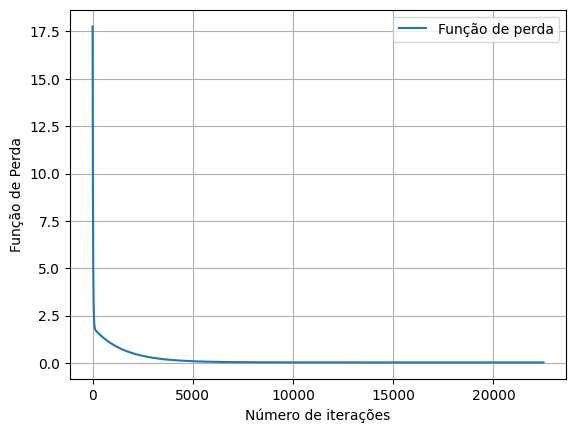

In [13]:
plt.plot(iteracoes, mse_lista, label='Função de perda')
plt.xlabel('Número de iterações')
plt.ylabel('Função de Perda')
plt.legend()
plt.grid()
plt.show()

O gráfico diminui drasticamente nas primeiras iterações, até que começa a diminuir mais suavemente (entre $0$ e $5000$ iterações). Depois disso, ele ainda não convergiu, mas diminui tão lentamente que não é visível na escala do gráfico.

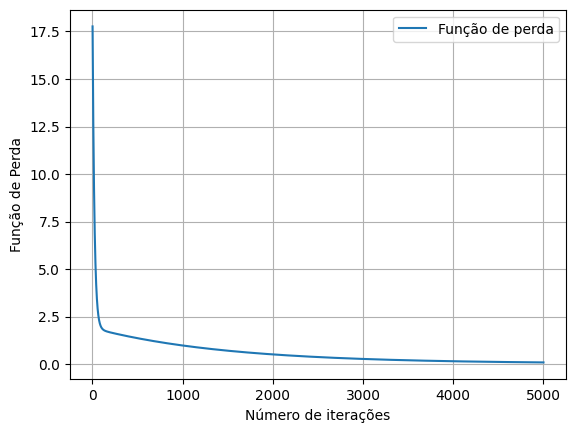

In [14]:
plt.plot(iteracoes[:5000], mse_lista[:5000], label='Função de perda')
plt.xlabel('Número de iterações')
plt.ylabel('Função de Perda')
plt.legend()
plt.grid()
plt.show()

Vendo até a iteração $5000$, podemos perceber melhor a queda abrupta e o decaimento lento posterior. Vamos ver, agora, entre $5000$ e $6000$ para vermos quão lenta é a convergência.

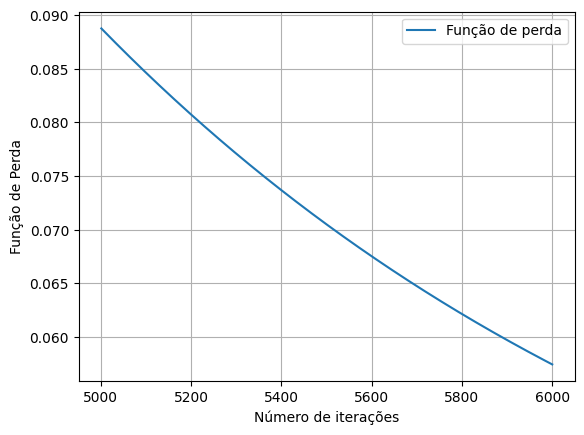

In [15]:
plt.plot(iteracoes[5000:6000], mse_lista[5000:6000], label='Função de perda')
plt.xlabel('Número de iterações')
plt.ylabel('Função de Perda')
plt.legend()
plt.grid()
plt.show()

Há uma variação de cerca de apenas $0.03$ nesse intervalo. Por isso precisamos de tantos passos para convergir de forma muito precisa. Conforme nos aproximamos do mínimo real, o decaimente da função de perda vai ficando cada vez mais lento. Para finalizar, abaixo estão as últimas $1000$ iterações.

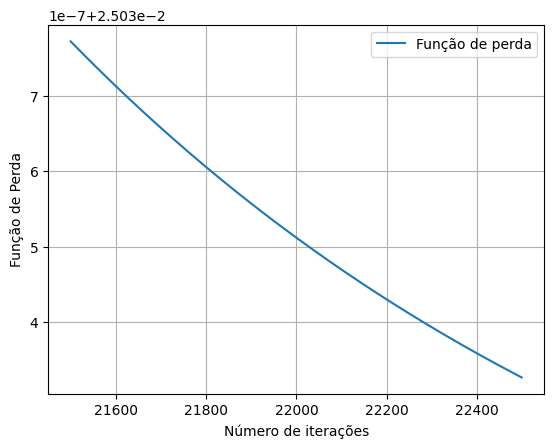

In [16]:
plt.plot(iteracoes[len(iteracoes)-1000:], mse_lista[len(iteracoes)-1000:], label='Função de perda')
plt.xlabel('Número de iterações')
plt.ylabel('Função de Perda')
plt.legend()
plt.grid()
plt.show()

A variação é ridiculamente pequena, sendo da ordem de $10^{-7}$.